In [ ]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import splrep, splev
from statsmodels.nonparametric.smoothers_lowess import lowess


def interpolate_data(values, num=1000):
    values = np.asarray(values, dtype=float)
    x = np.linspace(0, 1000, len(values))
    spl = splrep(x, values)
    new_x = np.linspace(0, 1000, num)
    new_values = splev(new_x, spl)
    return new_x, new_values


def normalize_by_max(values):
    values = np.asarray(values, dtype=float)
    vmax = values.max()
    
    if vmax == 0:
        return values
    
    return values / vmax
    

def normalize_data(list):
    list_max = max(list)
    normalized_data_1d = [ (data / list_max)for data in list]
    return normalized_data_1d


def find_baseline(values):

    values = np.array(values)   # or your existing list

    # 1. search minimum only in range 400-600
    search_region = values[400:601]   # 601 so index 600 is included
    min_idx_local = np.argmin(search_region)
    min_idx = min_idx_local + 400     # convert back to original index

    # 2. take 100 points around the minimum
    half_window = 50
    start = max(0, min_idx - half_window)
    end = min(len(values), min_idx + half_window)

    window = values[start:end]

    # 3. calculate average
    avg_100 = np.mean(window)

    return avg_100


def calculate_plot_parameter(intensities):
    average = np.mean(intensities, axis=0)
    average = lowess_smooth(average)

    stderr = np.std(intensities, axis=0) / np.sqrt(len(intensities))
    stderr = lowess_smooth(stderr)

    std = np.std(intensities, axis=0)
    std = lowess_smooth(std)

    return average, stderr, std


def lowess_smooth (data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.05 # IMPORTANT window length
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:,1]


def allinone(input_folder, timestamp_file):

    file_list = sorted(input_folder.glob("*.csv"))

    half_signal = []

    dye1_signal = []

    dye2_signal = []

    for i in range(len(file_list)):

        file = file_list[i]
        df = pd.read_csv(file)
        green_data = df["red"] # green == now red
        x_interp, green_signal = interpolate_data(green_data, num=1000)

        magenta_data = df["magenta"] # magenta == now magenta
        x_interp, magenta_signal = interpolate_data(magenta_data, num=1000)

        red_data = df["green"] # red == now green 
        x_interp, red_signal = interpolate_data(red_data, num=1000)
        df_time = pd.read_csv(timestamp_file, header=None)

        row = df_time.iloc[i]  

        timestamp1 = row[0]
        timestamp2 = row[1]
        timestamp3 = row[2]
        timestamp4 = row[3]

        time1_extend = int(1.2 * timestamp2 - 0.2 * timestamp1)
        time2_extend = int(1.2 * timestamp3- 0.2 * timestamp4)

        if time1_extend > time2_extend:
            print(f'overlap duration in {i}')

        left_signal = red_signal[timestamp1:time1_extend]
        right_signal = red_signal[time2_extend:timestamp4]

        _, interpolate_left = interpolate_data(left_signal, num=1000)
        _, interpolate_right = interpolate_data(right_signal, num=1000)

        baseline_left = np.mean(red_signal[timestamp2:time1_extend])
        baseline_right = np.mean(red_signal[time2_extend:timestamp3])

        relative_left = [(k/baseline_left)-1 for k in interpolate_left]
        relative_right = [(k/baseline_right)-1 for k in interpolate_right]

        interpolate_left_reverse = relative_left[::-1]

        average_sig = [(a + b) / 2 for a, b in zip(interpolate_left_reverse, relative_right)]

        half_signal.append(average_sig)

        # dye1
        dye1_data = green_signal[timestamp1:timestamp4]
        _, dye1_data_data = interpolate_data(dye1_data, num=1000)
        dye1_data_data_data = normalize_data(dye1_data_data)
        dye1_signal.append(dye1_data_data_data)

        # dye2
        dye2_data = magenta_signal[timestamp1:timestamp4]
        _, dye2_data_data = interpolate_data(dye2_data, num=1000)
        dye2_data_data_data = normalize_data(dye2_data_data)
        dye2_signal.append(dye2_data_data_data)

    return dye1_signal, dye2_signal, half_signal

# Figure 5D

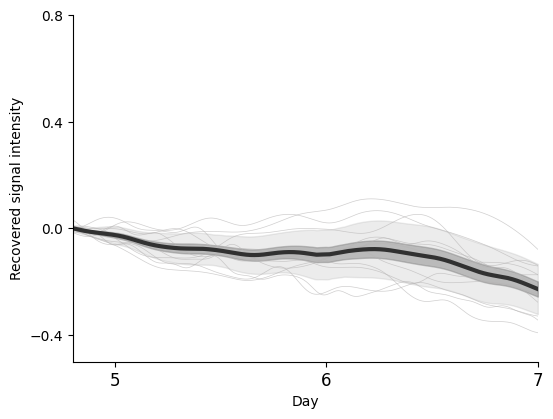

In [ ]:
input_folder = Path(r"fig5 control")
timestamp_file = r"fig5 control timestamp.csv"

dye1_signal, dye2_signal, half_signal = allinone(input_folder, timestamp_file)


def plot_3(intensities, average, stderr, std):
    plt.figure(figsize = (6,4.5))
    x = np.linspace(4.6, 7, len(average))   # create x axis from 4.6 to 7

    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=0.65, linewidth=0.5)

    plt.plot(x, average, color='#313131', linewidth=3, label='Average')

    plt.fill_between(x, average - stderr, average + stderr,
                     color='gray', alpha=0.45)

    plt.fill_between(x, average - std, average + std,
                     color='gray', alpha=0.15)

    plt.xlim(4.8, 7)
    plt.xticks([5, 6, 7], fontsize=12)
    # plt.axvline(5, color='gray', linestyle='--', alpha=0.6)

    plt.yticks([-0.4, 0,0.4, 0.8])
    plt.ylim(-0.5, 0.8)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Day")
    plt.ylabel("Recovered signal intensity")

    plt.show()


average_signal, stderr_signal, std_signal = calculate_plot_parameter(half_signal)
plot_3(half_signal, average_signal, stderr_signal, std_signal)

# Figure 5F

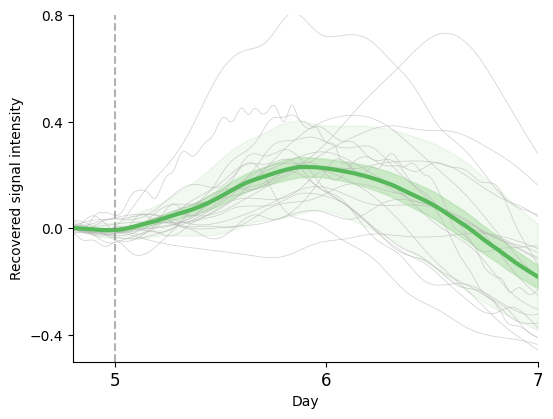

In [ ]:
input_folder = Path(r"fig5 FSK")
timestamp_file = r"fig5 FSK timestamp.csv"

dye1_signal, dye2_signal, half_signal = allinone(input_folder, timestamp_file)


def plot_3(intensities, average, stderr, std):
    plt.figure(figsize = (6,4.5))
    x = np.linspace(4.6, 7, len(average))   # create x axis from 4.8 to 7

    for data in intensities:
        plt.plot(x, data, color='#b6b4b4', alpha=0.65, linewidth=0.5)

    plt.plot(x, average, color="#56B85A", linewidth=3, label='Average')

    plt.fill_between(x, average - stderr, average + stderr,
                     color='#A1D99B', alpha=0.45)

    plt.fill_between(x, average - std, average + std,
                     color='#A1D99B', alpha=0.15)

    plt.xlim(4.8, 7)
    plt.xticks([5, 6, 7], fontsize=12)
    plt.axvline(5, color='gray', linestyle='--', alpha=0.6)

    plt.yticks([-0.4, 0,0.4, 0.8])
    plt.ylim(-0.5, 0.8)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.xlabel("Day")
    plt.ylabel("Recovered signal intensity")

    plt.show()

average_signal, stderr_signal, std_signal = calculate_plot_parameter(half_signal)
plot_3(half_signal, average_signal, stderr_signal, std_signal)

In [ ]:
import pandas as pd

def plot_single_trace (green_path, red_path, magenta_path):
    green_df = pd.read_csv(green_path, skiprows=[1])
    red_df = pd.read_csv(red_path, skiprows=[1])
    magenta_df = pd.read_csv(magenta_path, skiprows=[1])

    # extract coloumn
    green_df = green_df.iloc[:, 1]
    red_df = red_df.iloc[:, 1]
    magenta_df = magenta_df.iloc[:, 1]

    # interpolation
    _, green_trace = interpolate_data(green_df[::-1], num=1000)
    _, red_trace = interpolate_data(red_df[::-1], num=1000)
    _, magenta_trace = interpolate_data(magenta_df[::-1], num=1000)

    # smooth
    green_trace = lowess_smooth (green_trace)
    red_trace = lowess_smooth (red_trace)
    magenta_trace = lowess_smooth (magenta_trace)


    green_norm = normalize_by_max(green_trace)
    red_norm = normalize_by_max(red_trace)
    magenta_norm = normalize_by_max(magenta_trace)

    fig, axes = plt.subplots(4, 1, figsize=(5, 6))  # 4行1列

    # ===== 1. all =====
    
    axes[0].plot(red_norm, color='#f87977', linewidth=7, alpha=0.8)
    axes[0].plot(green_norm, color='#8cc63f', linewidth=7, alpha=0.8)
    axes[0].plot(magenta_norm, color='#ff88f4', linewidth=7, alpha=0.8)
    ymin = min(
        green_norm.min()-0.05,
        red_norm.min()-0.05,
        magenta_norm.min()-0.05
    )
    ymax = max(
        green_norm.max()+0.1,
        red_norm.max()+0.1,
        magenta_norm.max()+0.1
    )

    axes[0].set_ylim(ymin, ymax)
    axes[0].axis('off')


    # ===== 2. red =====
    axes[1].plot(red_trace, color='#f87977', linewidth=7)
    axes[1].axis('off')

    # ===== 3. magenta =====
    axes[2].plot(magenta_trace, color='#ff88f4', linewidth=7)
    axes[2].axis('off')

    # ===== 4. green =====
    axes[3].plot(green_trace, color='#8cc63f', linewidth=7)
    axes[3].axis('off')
    

    plt.tight_layout(pad=2)

    plt.show()

def lowess_smooth (data):
    x = np.linspace(0, 1, len(data))
    y = data

    frac = 0.03 # IMPORTANT window length
    lowess_result = lowess(y, x, frac=frac)

    return lowess_result[:,1]



# Figure 5C

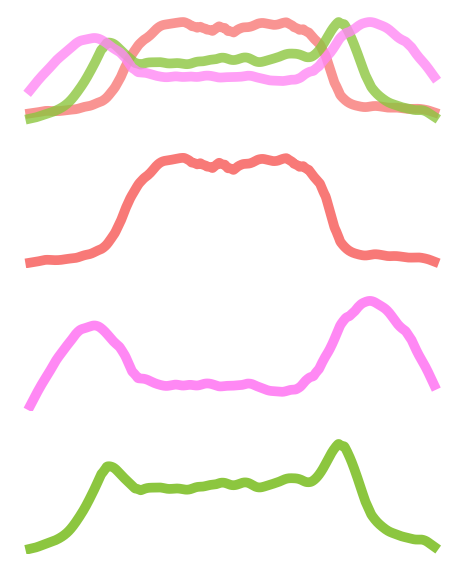

In [ ]:
green_path = r'examples\fsk example 1 green.csv'
magenta_path = r'examples\fsk example 1 magenta.csv'
red_path = r'examples\fsk example 1 image red.csv'

plot_single_trace (green_path, red_path, magenta_path)

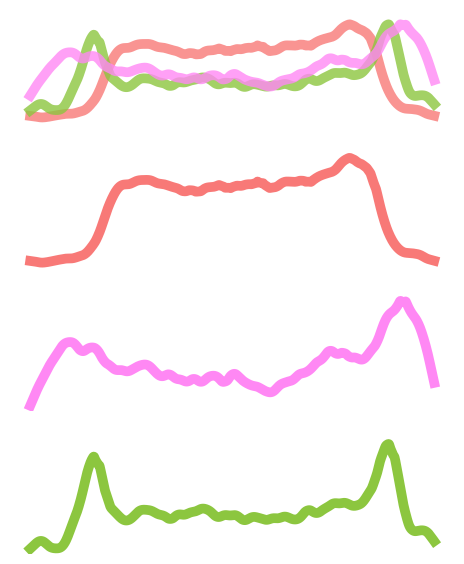

In [ ]:
green_path = r'examples\fsk example 2 green.csv'
magenta_path = r'examples\fsk example 2 magenta.csv'
red_path = r'examples\fsk example 2 image red.csv'

plot_single_trace (green_path, red_path, magenta_path)

# Figure 5E

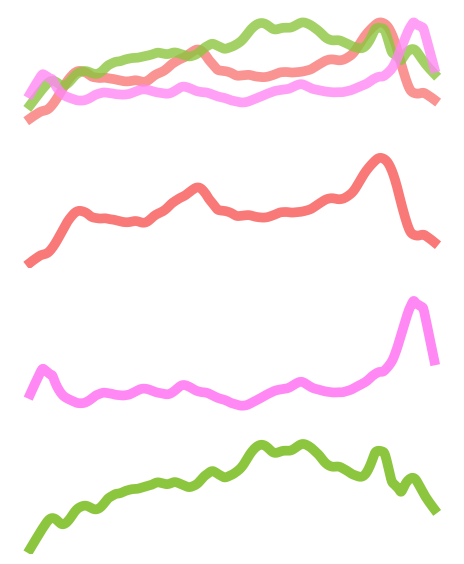

In [ ]:
green_path = r'examples\control example 1 green.csv'
magenta_path = r'examples\control example 1 magenta.csv'
red_path = r'examples\control example 1 red.csv'

plot_single_trace (green_path, red_path, magenta_path)

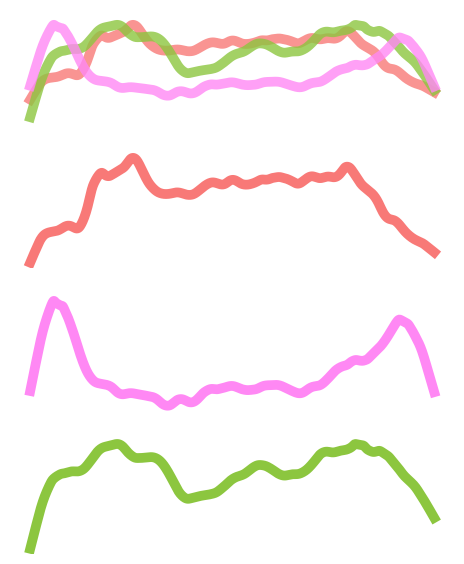

In [ ]:
green_path = r'examples\control example 2 green.csv'
magenta_path = r'examples\control example 2 magenta.csv'
red_path = r'examples\control example 2 red.csv'

plot_single_trace (green_path, red_path, magenta_path)